# Timing test: which data timing gives each model its best skill

For each model, test R² (all grid points) from the current, concurrent, and causal data. NNs are retrained, and the manuscript SR forms are refit, separately for each timing. Concurrent and causal share the same rain target ([T, T+3]), so they compare directly. The current rain window is one hour earlier, which the lag scan showed is slightly easier to predict (about 0.01 R² for B_L).

In [2]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import proplot as pplt
sys.path.insert(0,os.path.abspath('.'))
from timingutils import TimingConfig,load_dataset,calc_r2
from data import load_split
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
VARIANTS  = ['current','concurrent','causal']
COLORS    = {'current':'gray6','concurrent':'blue7','causal':'orange6'}
SPLIT     = 'test'
CONFIG    = TimingConfig()
MODELS    = [*CONFIG.timing['nn']['runs'],*CONFIG.timing['sr']['optimizedeqs']]
LABELS    = {**{name:run['description'] for name,run in CONFIG.nn['runs'].items()},
             **{name:eq['description'] for name,eq in CONFIG.sr['optimizedeqs'].items()}}
SAVEPATH  = os.path.join(CONFIG.resultsdir,'compare.jpg')

In [4]:
def calc_model_r2(config,name,truth):
    path = os.path.join(config.predsdir,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(path):
        return np.nan
    pred = load_dataset(path)['tp']
    if 'complexity' in pred.dims:
        pred = pred.isel(complexity=0)
    pred  = pred.transpose('time','lat','lon',...)
    grids = [pred.isel(seed=i).values for i in range(pred.sizes['seed'])] if 'seed' in pred.dims else [pred.values]
    return float(np.mean([calc_r2(truth,grid) for grid in grids]))

In [5]:
scores = {}
for variant in VARIANTS:
    config = TimingConfig(None if variant=='current' else variant)
    if variant!='current' and not os.path.exists(os.path.join(config.splitsdir,f'{SPLIT}.h5')):
        continue
    truth  = load_split(config,SPLIT)['tp'].transpose('time','lat','lon').values
    scores[variant] = {name:calc_model_r2(config,name,truth) for name in MODELS}
table = pd.DataFrame(scores).rename(index=LABELS)
table['best'] = table.apply(lambda row:row.idxmax() if row.notna().any() else '–',axis=1)
for variant in [v for v in scores if v!='current']:
    table[f'{variant} − current'] = table[variant]-table['current']
table.round(3)

,current,concurrent,causal,best,concurrent − current,causal − current
NN-BL,0.286,0.275,NaN,current,-0.011,NaN
NN-GAUSS,0.522,0.501,NaN,current,-0.020,NaN
SR-BL,0.293,0.275,NaN,current,-0.019,NaN
SR-ATM,0.336,0.321,NaN,current,-0.014,NaN
SR-SFC,0.397,NaN,NaN,current,NaN,NaN
SR-ALL,0.426,NaN,NaN,current,NaN,NaN
SR-ALL-PC,0.428,NaN,NaN,current,NaN,NaN


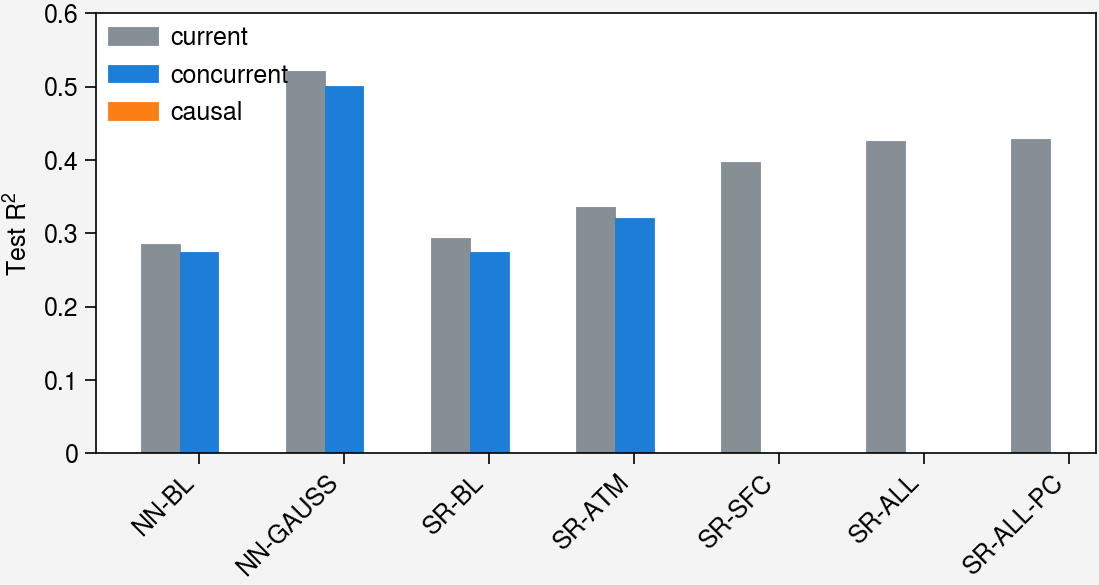

In [6]:
present = [v for v in VARIANTS if v in scores]
x       = np.arange(len(MODELS))
width   = 0.8/len(present)
fig,ax  = pplt.subplots(refwidth=5,refheight=2.2)
for i,variant in enumerate(present):
    values = [scores[variant][name] for name in MODELS]
    ax.bar(x+(i-(len(present)-1)/2)*width,values,width,color=COLORS[variant],label=variant)
ax.format(xlocator=x,xformatter=[LABELS[name] for name in MODELS],xrotation=45,xminorticks='none',
          ylabel=r'Test $R^2$',ylim=(0,0.6),grid=False)
ax.legend(loc='ul',ncols=1,frame=False)
pplt.show()
fig.save(SAVEPATH)